<a href="https://colab.research.google.com/github/grkenney/WinSPIRE-HLC-Python/blob/main/Notebooks/Day_2.3_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning

In this lesson, we'll continue working with our expression data set. So, let's load pandas with the pd nickname again and load our data file into a pandas data frame.

In [1]:
# load pandas with the nickname pd
import pandas as pd ##

In [2]:
# load the expression data set from the previous lessons
url = 'https://github.com/grkenney/WinSPIRE-HLC-Python/raw/refs/heads/main/data/sample_data_expression_06092026.csv'
df = pd.read_csv(url)

And since we'll be doing some very basic plotting in this lesson, we're going to run two additional lines of code. The first will tell python to show us our plots inline with our notebook, the second will import a new package called `matplotlib` with the nickname `plt`.

In [3]:
%matplotlib inline

import matplotlib as plt

Now that we've spent some time exploring the data and learning how to access different rows and columns of a data frame, we're going to apply those skills to do some real data analysis! 

Let's start by finding the average expression of `MTOR` across all data points.

In [4]:
# get the average expression of MTOR
sum(df["MTOR"]) / len(df)

nan

Is that what you expected? What do you think may have happened here?

## Cleaning our expression data
As we saw at the end of our last lesson, some of our columns contain data points with `nan`. In python, `nan` stands for "Not a Number". This usually means that the data for that measurement is missing. So, we need to "clean up" our data frame before we can proceed with our analysis. 

Let's check which of our columns contain missing values. To do this, we can use the `isany` method on our data frame again. And we can either count the number of missing values with the `sum` method or we can use the `any` method to test if any values are True in each of the columns. Let's try both.

In [5]:
# use isna followed by sum to count the number of missing values
df.isna().sum()

sample_id    0
well         0
timepoint    0
MKI67        6
MTOR         6
BAX          6
IRF1         6
dtype: int64

In [6]:
# use isna followed by the any method to test if each column contains any missing values
df.isna().any()

sample_id    False
well         False
timepoint    False
MKI67         True
MTOR          True
BAX           True
IRF1          True
dtype: bool

We can also use this method to check which rows have NAs. To do this, we have to set the `axis` parameter of `any` to 1.

In [7]:
# use isna followed by the any method to test if each row contains any missing values
df.isna().any(axis = 1)

0      False
1      False
2      False
3      False
4      False
       ...  
115    False
116    False
117    False
118    False
119    False
Length: 120, dtype: bool

How you handle missing values is going to vary depending on the data your working with. In this situation, missing values likely means that the expression of the gene was below the limit of detection. So, for this case, it makese sense to replace the `nan` values with zero.

Pandas has a very convenient method `fillna` that will let us fill in missing values with another value. Let's use `dropna` to drop all of the columns with missing values from the data set.

In [8]:
# use the fillna method to replace missing values with zero
df = df.dropna()

In [9]:
# check to see if we've successfully replaced the missing values
df.isna().any()

sample_id    False
well         False
timepoint    False
MKI67        False
MTOR         False
BAX          False
IRF1         False
dtype: bool

Awesome! We have no more missing values. So let's get back to what we were doing and get the average expression of `MTOR`.

In [10]:
# get the average expression of MTOR
sum(df["MTOR"]) / len(df)

2.975041996070706

That worked! While we can certainly use math to get column averages, pandas also has methods we can use to do the same thing.

Let's try to use the `mean` method to get the average expression of `MTOR`.

In [11]:
# get the average expression of MTOR
df["MTOR"].mean()

2.975041996070706

Missing values are very common in data sets, and generally we always want to check for them when opening a new data frame. Another thing we want to investigate is the distribution of the data to determine if there are any outliers.

While we are going to cover plotting more in depth later, it's sometimes a good idea to use some basic plots to visualize and quality control the data.

Pandas even has some built in methods for plotting that makes this easy. Let's try making a boxplot using the `hist` method to visualize the distribution of the expression for all genes in a histogram. Instead of typing out all of the gene names, let's also try doing this by indexing the column names using the `columns` attribute.

array([[<Axes: title={'center': 'MKI67'}>,
        <Axes: title={'center': 'MTOR'}>],
       [<Axes: title={'center': 'BAX'}>,
        <Axes: title={'center': 'IRF1'}>]], dtype=object)

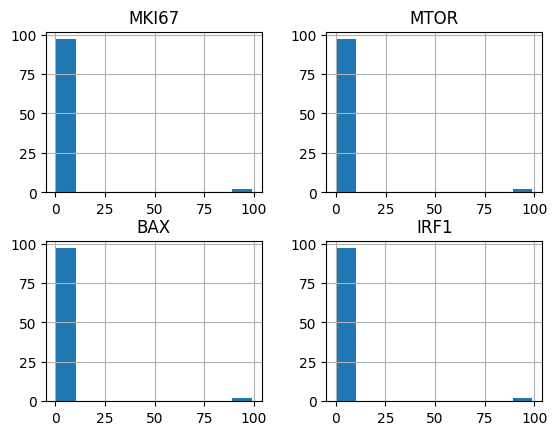

In [12]:
# use the columns attribute and subsetting to store the gene column names in a variable columns
columns = df.columns[3:]

# index df to only gene columns and use the hist method to visualize the expression data 
df[columns].hist()

It looks like most of our data has expression values below 10. But it we look closely, there are a few data points above 75.

Thinking back to the previous lesson, we know that the maximum expression value for some of our genes was 99. Here, we can see that that value seems to be an outlier, so let's clean up the data a little more. Let's say that the instrument used in this experiment will sometimes produce a value of 99 when detection is below the lower limit of detection.

One way to deal with this issue in qPCR data is to replace values below the limit of detection with half of the limit of detection value. Let's say our limit of detection here is 0.1.

So, let's replace all occurences of 99 in our expression data with 0.05. We can use the `replace` method to do this.

In [13]:
# replace the value 99 with 0 in the columns with our expression information
df[columns] = df[columns].replace(99, 0.05)

**COULD ALSO REPLACE WITH MIN VALUE**

array([[<Axes: title={'center': 'MKI67'}>,
        <Axes: title={'center': 'MTOR'}>],
       [<Axes: title={'center': 'BAX'}>,
        <Axes: title={'center': 'IRF1'}>]], dtype=object)

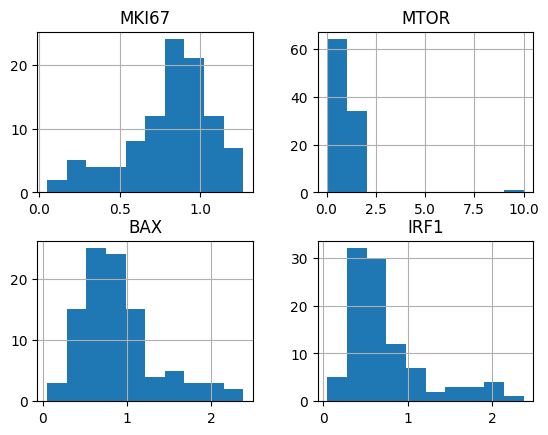

In [14]:
# try making another histogram
df[columns].hist()

That looks much more reasonable!

**Exercise:** now that our data has changed, let's calculate some statistics on our data. Try calculating each of these statistics for all genes. There are multiple ways to do this, using either python functions or methods on the pandas data frame.
* Average expression
* Maximum expression
* Minimum expression
* Median expression

In [15]:
# calculate average expression for all genes
df[columns].mean()

MKI67    0.804396
MTOR     0.976052
BAX      0.896889
IRF1     0.744928
dtype: float64

In [16]:
df[columns].max()

MKI67     1.265415
MTOR     10.000000
BAX       2.383608
IRF1      2.375526
dtype: float64

In [17]:
df[columns].min()

MKI67    0.05
MTOR     0.05
BAX      0.05
IRF1     0.05
dtype: float64

In [18]:
df[columns].median()

MKI67    0.855077
MTOR     0.911983
BAX      0.800381
IRF1     0.643022
dtype: float64

# Meta data
So far, we've just been exploring the expression data for this experiment. But, we also have meta data for this experiment. Let's load in that data frame and explore it a little bit.

In [19]:
url = "https://github.com/grkenney/WinSPIRE-HLC-Python/raw/refs/heads/main/data/meta_data_expression_07062026.csv"

# load in the above url into a pandas data frame in a variable called "meta"
meta = pd.read_csv(url)

Let's take a look at the first few rows of our data frame.

In [20]:
meta.head()

,sample_id,treatment_group
0,657317,Control
1,407401,Control
2,835249,control
3,490084,Treatment
4,452567,Treatment


Here we have two columns, the first is `sample_id` which matches the `sample_id` column in our expression data. The second column is `treatment_group` which gives us information about how the samples were treated. This information is going to be helpful as we continue analyzing our data.

**Exercise:** First, try exploring this new data frame on your own. Try answering the following questions:
* How many rows are in our data frame?
* What data type is in each column?
* How would you access all rows where the column `treatment_group` is "Treatment"?
* Try using the `unique` method on the `treatment_group` column to print the unique group names.
* Is there something about this column that needs to be "cleaned"? Try using the skills we learned in this lesson to clean up this data. 

In [21]:
# how many columns are in the data frame?
meta.shape
len(meta.columns)

2

In [22]:
# what data types are in each column?
meta.dtypes

sample_id           int64
treatment_group    object
dtype: object

In [23]:
# how would you access all rows where treatment_group is "Treatment"
meta.query("treatment_group == 'Treatment'")

,sample_id,treatment_group
3,490084,Treatment
4,452567,Treatment
6,994571,Treatment
7,248286,Treatment
8,840149,Treatment
9,804190,Treatment
16,994861,Treatment
17,248138,Treatment
19,769101,Treatment
21,569324,Treatment


In [24]:
# subset meta to the treatment_group column and use the unique() method
meta["treatment_group"].unique()

array(['Control', 'control', 'Treatment'], dtype=object)

In [25]:
# clean up the treatment_group column
meta["treatment_group"] = meta["treatment_group"].replace("control", "Control")

In [26]:
# recheck unique treatment_group values to make sure it worked
meta["treatment_group"].unique()

array(['Control', 'Treatment'], dtype=object)

# Merging

While we could manually look at this table to decode how each sample id is treated, it would be helpful to combine the two data frames together so we have all of the information in one place. This is called "merging".

Pandas has a function `merge` that we can use for this.

In [27]:
# merge meta and df with an outer join on sample_id
pd.merge(meta, df, how = "outer", on = "sample_id")

,sample_id,treatment_group,well,timepoint,MKI67,MTOR,BAX,IRF1
0,657317,Control,1.0,0.0,1.004377,1.379025,0.799135,0.672194
1,657317,Control,2.0,8.0,0.894172,1.345400,0.956142,0.756379
2,657317,Control,3.0,16.0,0.679445,1.098444,1.209928,0.050000
3,657317,Control,4.0,24.0,0.721341,1.063588,1.586136,0.643022
4,407401,Control,5.0,0.0,1.091682,0.843497,0.354864,0.489234
...,...,...,...,...,...,...,...,...
95,871144,Control,27.0,0.0,0.881421,1.514194,0.660141,0.490321
96,871144,Control,28.0,8.0,0.817965,1.407120,0.815591,0.537545
97,871144,Control,29.0,16.0,0.708894,1.197898,0.972522,0.499416
98,871144,Control,30.0,24.0,0.541472,1.092223,1.341830,0.534427


Great! Now we have a new column in our data frame called `treatment_group` that tells us what group each of our samples are in.

Now that we've got all of our data in once place, lets save this merged data frame in a variable called `data`.

In [28]:
data = pd.merge(meta, df, how = "outer", on = "sample_id")

After merging, it's always a good idea to check that the shape of your data is what you expect. Let's check the number of rows and columns in our starting data set and compare it to the merged data set.

In [29]:
# print the shape of df
df.shape

(99, 7)

In [30]:
# print the shape of data
data.shape

(100, 8)

Are those numbers what you expected?

Our original data set had 120 rows and 7 columns. The new data set has 121 rows and 8 columns. The new column is from adding the `treatment_group` column. But what about the new row?

Let's check if there are any NAs in our data frame

In [31]:
# check which columns contain NAs
data.isna().any()

sample_id          False
treatment_group    False
well                True
timepoint           True
MKI67               True
MTOR                True
BAX                 True
IRF1                True
dtype: bool

It looks like our merge introduced one row with NAs. This is because there was a sample id in our meta data that wasn't in our original data set. Since we have no data for this sample, we don't need to include it in our analyses. We could use `dropna` again to solve this, but instead, let's try merging our data a different way.

Use an "inner" merge to exclude data that isn't matched between the tables.

In [32]:
# merge meta and df with an inner join on sample_id
data = pd.merge(meta, df, how = "inner", on = "sample_id")
data

,sample_id,treatment_group,well,timepoint,MKI67,MTOR,BAX,IRF1
0,657317,Control,1,0,1.004377,1.379025,0.799135,0.672194
1,657317,Control,2,8,0.894172,1.345400,0.956142,0.756379
2,657317,Control,3,16,0.679445,1.098444,1.209928,0.050000
3,657317,Control,4,24,0.721341,1.063588,1.586136,0.643022
4,407401,Control,5,0,1.091682,0.843497,0.354864,0.489234
...,...,...,...,...,...,...,...,...
94,199598,Treatment,26,24,0.346927,0.144315,1.302101,1.838012
95,871144,Control,27,0,0.881421,1.514194,0.660141,0.490321
96,871144,Control,28,8,0.817965,1.407120,0.815591,0.537545
97,871144,Control,29,16,0.708894,1.197898,0.972522,0.499416


Let's check the shape of the data again to make sure we get the expected number of rows now.

In [33]:
data.shape

(99, 8)

Great! We have 120 rows now, which matches the number of rows in our original data set!

You've just learned:

* How to merge two different data frames.
* How to use different types of merges.

# Group By

Earlier in the lesson, we learned how to find minimum and maximum values for `MTOR`, but, now that we have more informaiton about the samples, it might also be helpful to calculate those statistics within each treatment group.

To do this, we can use a method called `groupby`. Group by allows us to split a data frame into groups based on one or more columns. Let's try it here to find the max expression value of MTOR for each treatment group.

In [34]:
# use groupby to group data by treatment_group
treat_grouping = data.groupby("treatment_group")

In [35]:
# find the max value of MTOR for each treatment_group
treat_grouping["MTOR"].max()

treatment_group
Control      10.000000
Treatment     1.508504
Name: MTOR, dtype: float64

We can also use `groupby` to group on multiple columns in our data frame. We can use this to ask more compex questions like what are the maximum expression values of MTOR for each treatment group and timepoint?

In [36]:
# group on both treatment_group and timepoint
treat_0_grouping = data.groupby(["treatment_group", "timepoint"])

In [37]:
treat_0_grouping["MTOR"].max()

treatment_group  timepoint
Control          0             1.587871
                 8             1.407120
                 16           10.000000
                 24            1.092223
Treatment        0             1.508504
                 8             1.303526
                 16            0.752716
                 24            0.554897
Name: MTOR, dtype: float64

**Exercise:** Try using what you just learned about groupby to do the following:
* Use the `mean` method to find the average value of BAX for each timepoint
* Find the the maximum expression of both MTOR and IRF1 in each treatment group at the same time
* Try using the `size` method to find how many rows we have for each treatment group
* Check if we have an equal number of timepoints for each treatment group.
    * You'll need to group on multiple columns
    * You can also use the `size` function for this

In [38]:
# find the average expression of BAX for each timepoint
data.groupby("timepoint")["BAX"].mean()

timepoint
0     0.587392
8     0.770119
16    0.982538
24    1.334459
Name: BAX, dtype: float64

In [39]:
# find the minimum expression of both MTOR and IRF1 for each treatment group at the same time
data.groupby("treatment_group")[["MTOR", "IRF1"]].max()

,MTOR,IRF1
treatment_group,,
Control,10.000000,0.775356
Treatment,1.508504,2.375526


In [40]:
# find number of rows per treatment group
data.groupby("treatment_group").size()

treatment_group
Control      53
Treatment    46
dtype: int64

In [41]:
# find the number of timepoints for each treatment group
data.groupby(["treatment_group", "timepoint"]).size()

treatment_group  timepoint
Control          0            14
                 8            14
                 16           14
                 24           11
Treatment        0            12
                 8            14
                 16            9
                 24           11
dtype: int64

You've just learned:

* How to group data within a data frame using `groupby`.
* How to calculate statistics on customized groupings of data in a data frame.

# Saving data frames

We did a lot of work with our data today and we now have a cleaned and merged data frame that's ready to analyze and plot with. Before we end, let's make sure we save our data so we don't have to do it all again next time.

Because we are working in google collab, we have to mount our google drive in this notebook and authenticate. If you are running python on your computer or somewhere else, this next code chunk probably won't be necessary.

In [ ]:
from google.colab import drive
drive.mount('drive')

Now let's save our data into a csv file.

In [ ]:
# make sure you save your data frame!
data.to_csv('/drive/My Drive/Colab Notebooks/qPCR_data.csv')